In [1]:
import ast
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.multioutput import MultiOutputClassifier

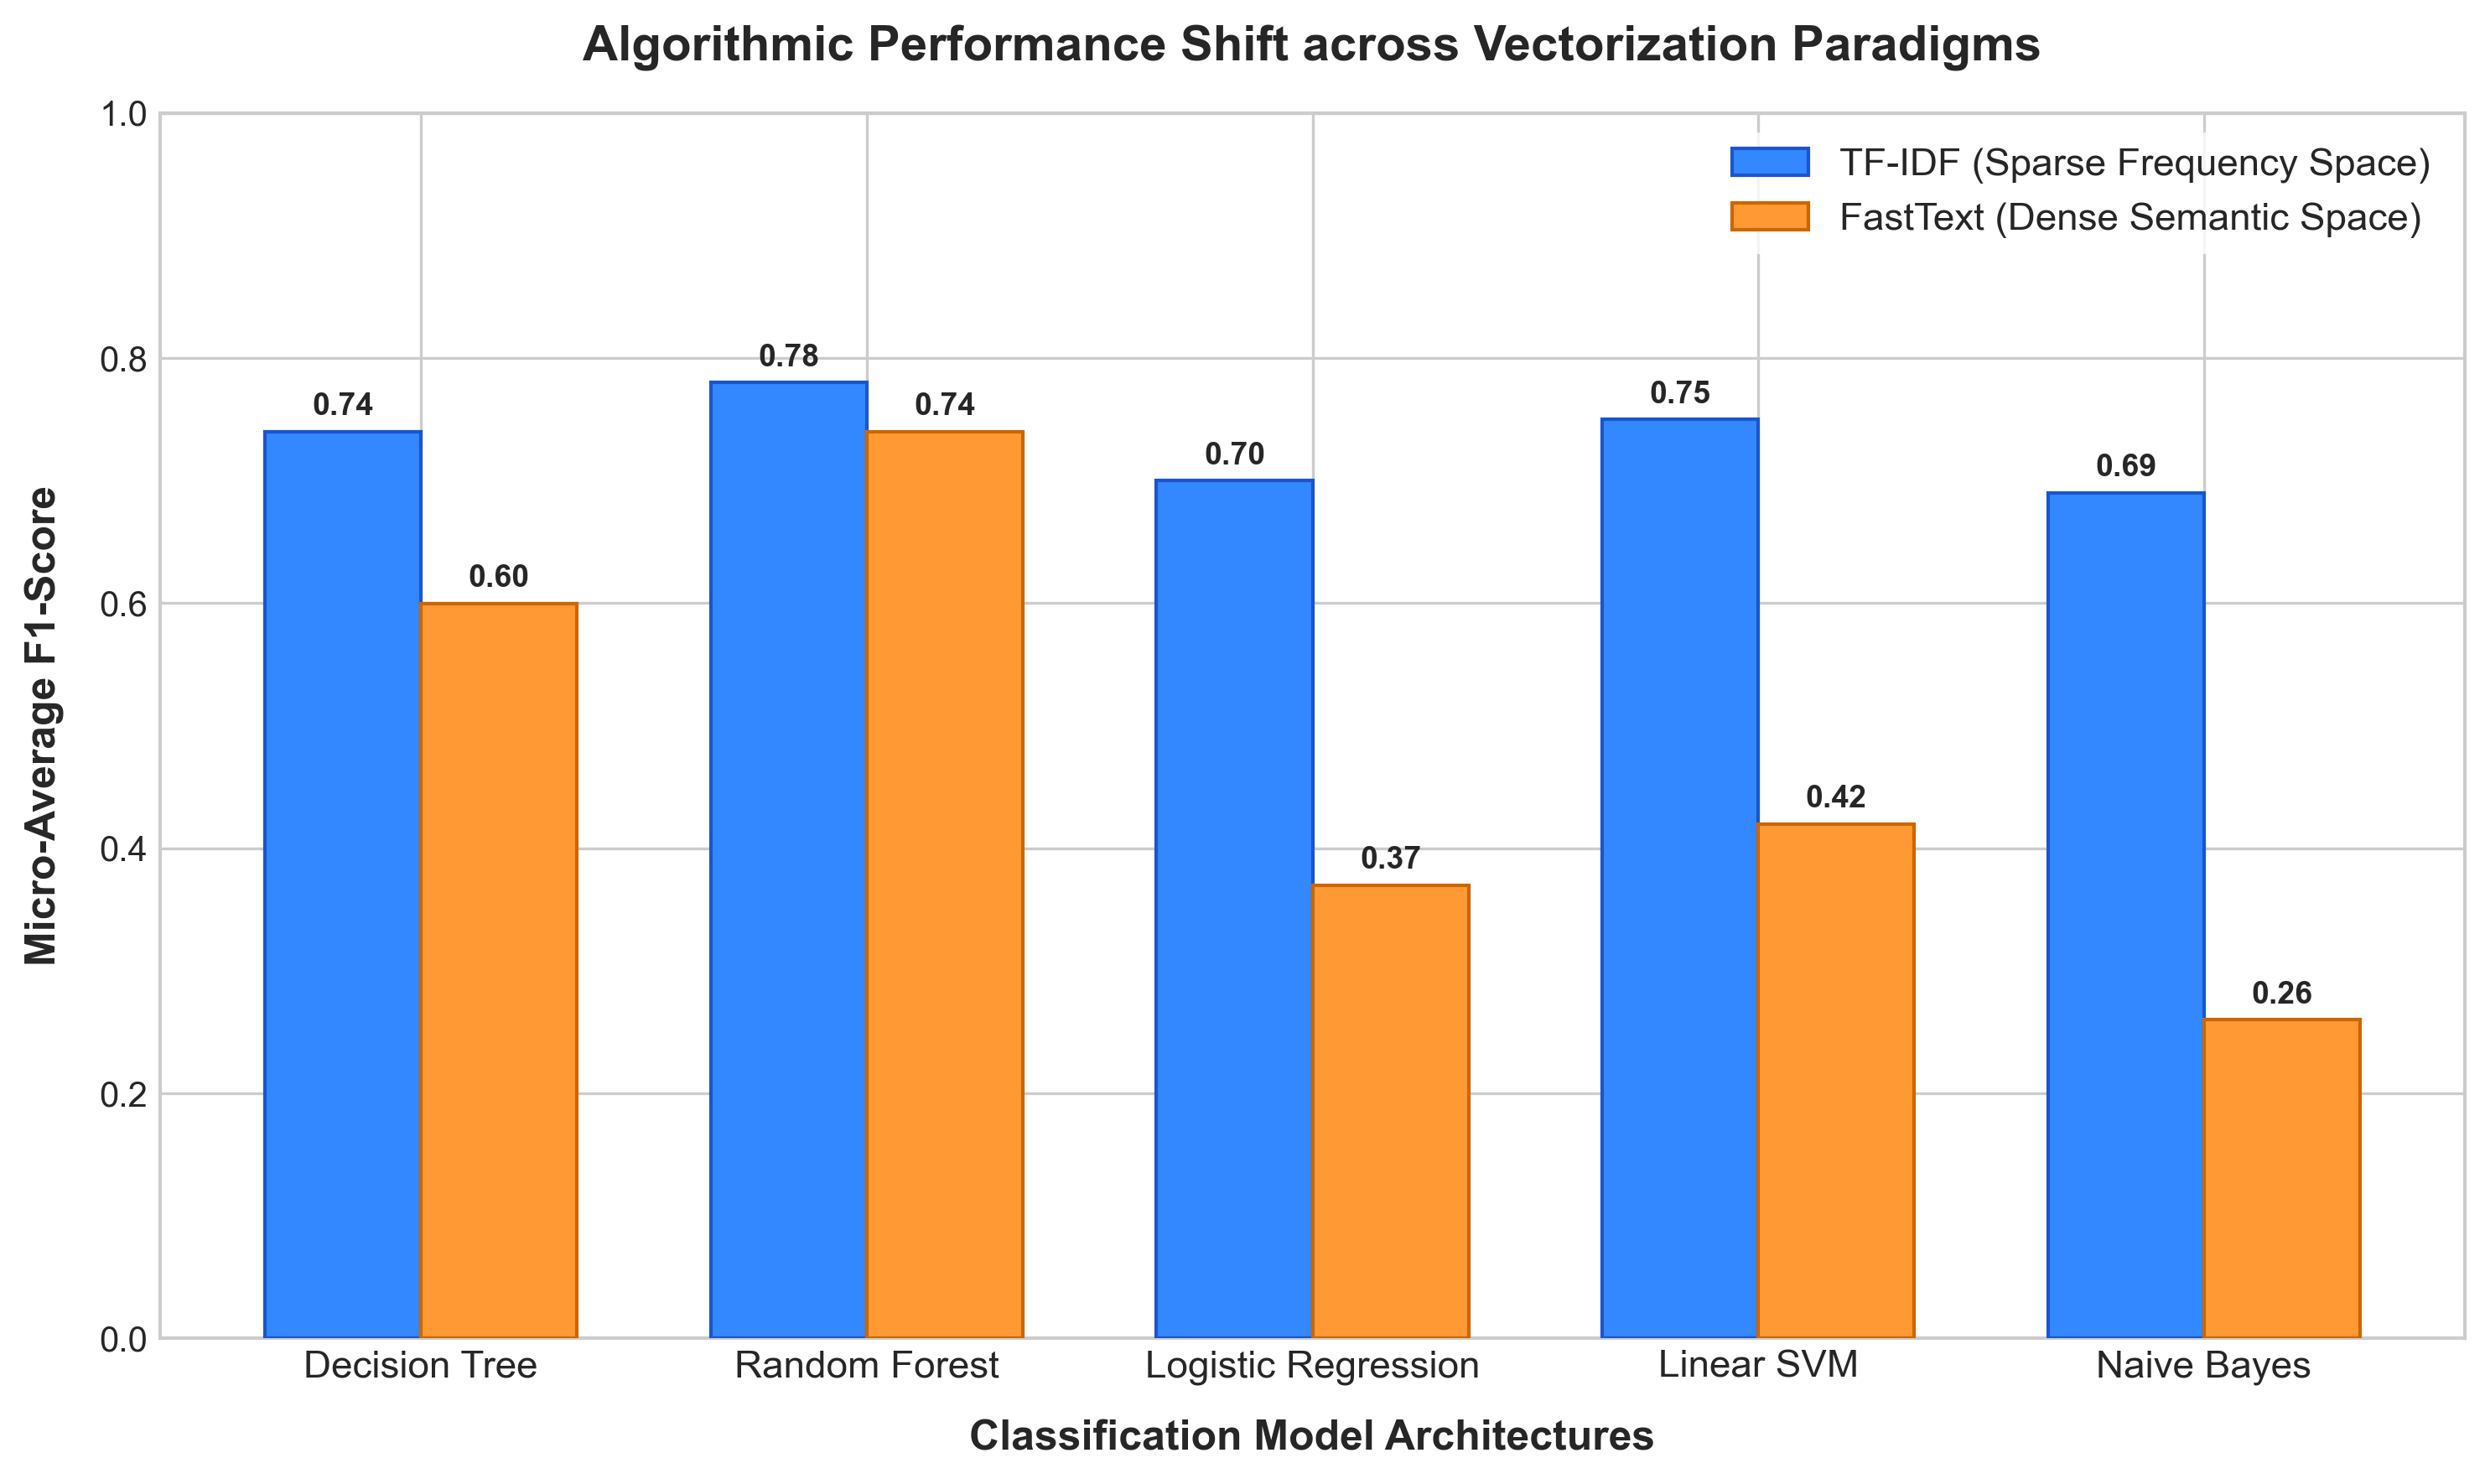

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

classifiers = [
    'Decision Tree', 
    'Random Forest', 
    'Logistic Regression', 
    'Linear SVM', 
    'Naive Bayes'
]

tf_idf_scores = [0.74, 0.78, 0.70, 0.75, 0.69]
fasttext_scores = [0.60, 0.74, 0.37, 0.42, 0.26]

x = np.arange(len(classifiers))  
width = 0.35  

rects1 = ax.bar(x - width/2, tf_idf_scores, width, label='TF-IDF (Sparse Frequency Space)', color='#3388ff', edgecolor='#1a55cc', zorder=3)
rects2 = ax.bar(x + width/2, fasttext_scores, width, label='FastText (Dense Semantic Space)', color='#ff9933', edgecolor='#cc6600', zorder=3)

ax.set_ylabel('Micro-Average F1-Score', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Classification Model Architectures', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Algorithmic Performance Shift across Vectorization Paradigms', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(classifiers, fontsize=11)
ax.set_ylim(0, 1.0)

ax.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', edgecolor='none')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

plt.savefig('classifier_performance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import json
import os


try:
    df = pd.read_csv("labelled-messages.csv")
    print(f"Successfully loaded {len(df)} messages from Downloads.")
except FileNotFoundError:
    print(f"Error: File not found at {downloads_path}. Please check the filename.")



Successfully loaded 11405 messages from Downloads.


In [4]:
def extract_attributes(state_str):
    if pd.isna(state_str):
        return pd.Series([None]*8)
    try:
        data = json.loads(state_str)
        
        category = data.get('level1', {}).get('category', [])
        
        supply_dict = data.get('level3', {}).get('supplyMode', {})
        supply_mode = next((k.upper() for k, v in supply_dict.items() if v is True and k != 'enabled'), 'UNKNOWN')
        
        tool_type = [k for k, v in data.get('level3', {}).get('tool', {}).get('types', {}).items() if v is True]
        
        difi_infrastructure = [k for k, v in data.get('level3', {}).get('digitalInfrastructure', {}).get('types', {}).items() if v is True]
        
        data_types = [k for k, v in data.get('level3', {}).get('data', {}).get('types', {}).items() if v is True]
        
        account_types = [k for k, v in data.get('level4', {}).get('account', {}).get('types', {}).items() if v is True]
        
        cap_data = data.get('level4', {}).get('capability', {})
        main_capability = cap_data.get('mainCapability', None)
        cap_data = data.get('level4', {}).get('capability', {})
        raw_main = cap_data.get('mainCapability', "")
        
        if isinstance(raw_main, str) and "," in raw_main:
            main_capability = [i.strip() for i in raw_main.split(",")]
        elif raw_main:
            main_capability = [raw_main]
        else:
            main_capability = []

        other_capability = [k for k, v in cap_data.get('auxiliary', {}).items() if v is True]     
        
        return pd.Series([
            category, supply_mode, tool_type, difi_infrastructure, 
            data_types, account_types, main_capability, other_capability
        ])
    except (json.JSONDecodeError, TypeError):
        return pd.Series(['STROKE']*8)

new_cols = ['category', 'supply_mode', 'tool_type', 'difi_infrastructure', 
            'data_types', 'account_types', 'main_capability', 'other_capability']
df[new_cols] = df['state'].apply(extract_attributes)

# display(df[['message_id', 'sender_id', 'text'] + new_cols].head(10))

mask = df['category'].astype(str).apply(lambda x: 'DATA_AD' in x)

df_data_ad = df[mask]

display(df_data_ad[['message_id', 'text'] + new_cols].head(20))


,message_id,text,category,supply_mode,tool_type,difi_infrastructure,data_types,account_types,main_capability,other_capability
74,157462981,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"
154,157463199,🔤🔤🔤🔤🔤🔤🔤🔤🔤✅\n🍑Hotmail and Outlook Hacking\n🍑Sky...,"[DATA_AD, UTILITY_AD]",PRODUCT,"[malware, phishing]",[],"[cardingData, personalData, loginCredentials]","[email, social, financial]",[INITIAL_ACCESS],"[collection, resourceDev, credentialAccess]"
342,157465890,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"
343,157464051,🅰💗🔠 ➖💓🔤🔠🔠🔤🅰️🔠\n\n\n🪐SMS PANEL & GATEWAY 🪐\n➡️S...,"[UTILITY_AD, DATA_AD]",PRODUCT,[spam],[hosting],[other],"[cloud, email]",[EXECUTION],"[discovery, collection]"
405,157464499,44cc with spoofing line or simple cc line avai...,[DATA_AD],PRODUCT,[],[],[cardingData],[financial],[RESOURCE_DEVELOPMENT],[impact]
477,157475075,🇪🇦🇪🇦 Spain Bank targeted leads available. \n\n...,[DATA_AD],PRODUCT,[],[],[personalData],[financial],[COLLECTION],"[discovery, resourceDev]"
506,157465193,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"
547,157465246,🔤🔤🔤🔤🔤🔤🔤🔤🔤✅\n🍑Hotmail and Outlook Hacking\n🍑Sky...,"[DATA_AD, UTILITY_AD]",PRODUCT,"[malware, phishing]",[],"[cardingData, personalData, loginCredentials]","[email, social, financial]",[INITIAL_ACCESS],"[collection, resourceDev, credentialAccess]"
577,157466003,📱📞Reliable & Affordable Voice Communication\n\...,"[UTILITY_AD, DATA_AD]",PRODUCT,[spam],[],"[cardingData, personalData]","[email, financial]",[DISCOVERY],"[collection, lateralMovement]"
583,157466013,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"


In [5]:
import emoji

df_clean = df.copy()


df_clean['text'] = df_clean['text'].astype(str).apply(lambda x: emoji.replace_emoji(x, replace=''))

df_clean = df_clean[df_clean['category'] != 'STROKE']

mask = df_clean["supply_mode"] == "UNKNOWN"
df_clean.loc[mask, "category"] = [["NOT_RELEVANT"]] * mask.sum()

display(df_clean.head())

,message_id,in_community_id,community_id,sender_id,date,nrof_forwards,views,media_type,forward_id,text,reply_to_msg_id,state,category,supply_mode,tool_type,difi_infrastructure,data_types,account_types,main_capability,other_capability
0,157462925,109602,1574556170,1282470244,2025-07-30,34,4251,none,NaN,"AUTO DIALERS – Automate, Accelerate & Scale\n...",NaN,"{""level1"": {""category"": [""UTILITY_AD""]}, ""leve...",[UTILITY_AD],SERVICE,[spam],[],[],[hosting],[DISCOVERY],[lateralMovement]
1,157462926,109603,1574556170,6610303182,2025-07-30,0,0,none,NaN,\n\nNOW AVAILABLE \n\nDELIVER STRAIGHT TO INB...,NaN,"{""level1"": {""category"": [""UTILITY_AD""]}, ""leve...",[UTILITY_AD],SERVICE,[],[],[loginCredentials],[email],[INITIAL_ACCESS],"[collection, lateralMovement]"
2,119609298,79467,2032937185,5805122541,2025-04-12,0,0,none,NaN,(Google Cloud)\n\n $300 & $350 Credit \n\n C...,NaN,"{""level1"": {""category"": [""DATA AD""]}, ""level2""...",[DATA AD],PRODUCT,[],[],[loginCredentials],"[cloud, hosting]",[RESOURCE DEVELOPMENT],"[initialAccess, credentialAccess]"
3,35317032,49733,2060889807,5475549371,2024-06-03,0,0,none,NaN,I buying linode hq account (not port check)\nc...,NaN,"{""level1"": {""category"": [""DATA AD""]}, ""level2""...",[DATA AD],PRODUCT,[],[],[loginCredentials],"[cloud, hosting]",[RESOURCE DEVELOPMENT],"[initialAccess, credentialAccess]"
4,157462927,109604,1574556170,7752711911,2025-07-30,0,0,none,NaN,USA CLI VoIP & VPN Services — All in One Plac...,NaN,"{""level1"": {""category"": [""UTILITY_AD""]}, ""leve...",[UTILITY_AD],SERVICE,[],[],[],[vpn],[RESOURCE_DEVELOPMENT],[discovery]


In [6]:
print("--- Filtering for PERSISTENCE or PRIVILEGE_ESCALATION ---")

target_caps = {'PERSISTENCE', 'PRIVILEGE_ESCALATION'}

mask = df_clean['main_capability'].apply(lambda x: bool(set(x) & target_caps))

df_targeted = df_clean[mask]

print(f"Found {len(df_targeted)} messages matching those capabilities.\n")

display(df_targeted[['message_id', 'text', 'main_capability']])

--- Filtering for PERSISTENCE or PRIVILEGE_ESCALATION ---
Found 0 messages matching those capabilities.



,message_id,text,main_capability


In [7]:
print("--- Checking 'NOT_RELEVANT' Messages ---")

mask = df_clean['category'].apply(lambda x: 'NOT_RELEVANT' in x)
total_not_relevant = mask.sum()

print(f"Total messages labeled 'NOT_RELEVANT' in the dataset: {total_not_relevant}")

df_nr_samples = df_clean[mask]

if total_not_relevant > 0:
    print("\nDisplaying samples of 'NOT_RELEVANT' messages:")
    display(df_nr_samples[['message_id', 'text', 'category']].head(10))
else:
    print("\nWarning: No messages found with the exact label 'NOT_RELEVANT'. Check your cleaning step!")

--- Checking 'NOT_RELEVANT' Messages ---
Total messages labeled 'NOT_RELEVANT' in the dataset: 1391

Displaying samples of 'NOT_RELEVANT' messages:


,message_id,text,category
9,157462931,This channel can’t be displayed because it vio...,NOT_RELEVANT
35,110883637,Anyone know how to change ip for android ?? Fr...,NOT_RELEVANT
47,115558272,"Who need buyers this target\n\ngiffgaff ,info....",NOT_RELEVANT
89,157462998,nan,NOT_RELEVANT
108,157463153,This channel can’t be displayed because it vio...,NOT_RELEVANT
125,147404205,Anytype of current account if you have dm me a...,NOT_RELEVANT
134,157463180,U,NOT_RELEVANT
157,106058778,Cash app transfer still hitting come BTC ready...,NOT_RELEVANT
204,119584935,Digital Ocean \n\n10 drop \nCredit 200$\ngood ...,NOT_RELEVANT
205,157463586,This channel can’t be displayed because it vio...,NOT_RELEVANT


In [8]:
def final_label_cleaner(val):
    if isinstance(val, str):
        val = [val]
    
    if not isinstance(val, list):
        return []
    
    cleaned_set = set()
    for item in val:
        item_str = str(item).upper().strip().replace('[', '').replace(']', '').replace(' ', '_')
        if item_str:
            cleaned_set.add(item_str)
    return list(cleaned_set)

# 1. Apply the clean
df_clean['category'] = df_clean['category'].apply(final_label_cleaner)


In [9]:
print("--- Checking 'NOT_RELEVANT' Messages ---")

mask = df_clean['category'].apply(lambda x: 'NOT_RELEVANT' in x)
total_not_relevant = mask.sum()

print(f"Total messages labeled 'NOT_RELEVANT' in the dataset: {total_not_relevant}")

df_nr_samples = df_clean[mask]

if total_not_relevant > 0:
    print("\nDisplaying samples of 'NOT_RELEVANT' messages:")
    display(df_nr_samples[['message_id', 'text', 'category']].head(10))
else:
    print("\nWarning: No messages found with the exact label 'NOT_RELEVANT'. Check your cleaning step!")

--- Checking 'NOT_RELEVANT' Messages ---
Total messages labeled 'NOT_RELEVANT' in the dataset: 1392

Displaying samples of 'NOT_RELEVANT' messages:


,message_id,text,category
9,157462931,This channel can’t be displayed because it vio...,[NOT_RELEVANT]
35,110883637,Anyone know how to change ip for android ?? Fr...,[NOT_RELEVANT]
47,115558272,"Who need buyers this target\n\ngiffgaff ,info....",[NOT_RELEVANT]
89,157462998,nan,[NOT_RELEVANT]
108,157463153,This channel can’t be displayed because it vio...,[NOT_RELEVANT]
125,147404205,Anytype of current account if you have dm me a...,[NOT_RELEVANT]
134,157463180,U,[NOT_RELEVANT]
157,106058778,Cash app transfer still hitting come BTC ready...,[NOT_RELEVANT]
204,119584935,Digital Ocean \n\n10 drop \nCredit 200$\ngood ...,[NOT_RELEVANT]
205,157463586,This channel can’t be displayed because it vio...,[NOT_RELEVANT]


In [10]:
print("--- Dropping single-instance label combinations for stratification ---")

df_clean['combo_proxy'] = df_clean['category'].astype(str)

combo_counts = df_clean['combo_proxy'].value_counts()

valid_combos = combo_counts[combo_counts >= 2].index
df_clean = df_clean[df_clean['combo_proxy'].isin(valid_combos)].copy()

df_clean = df_clean.drop(columns=['combo_proxy'])

print(f"Dataset size after filtering rare combinations: {len(df_clean)} messages.")

--- Dropping single-instance label combinations for stratification ---
Dataset size after filtering rare combinations: 11400 messages.


In [11]:
import ast

valid_capabilities = {
    "RECONNAISSANCE", "RESOURCE_DEVELOPMENT", "INITIAL_ACCESS",
    "EXECUTION", "PERSISTENCE", "PRIVILEGE_ESCALATION",
    "DEFENSE_EVASION", "CREDENTIAL_ACCESS", "DISCOVERY",
    "LATERAL_MOVEMENT", "COLLECTION", "COMMAND_AND_CONTROL",
    "EXFILTRATION", "IMPACT"
}

def enforce_handbook_caps(val):
    if isinstance(val, list):
        parsed_list = val
    elif isinstance(val, str):
        if val.startswith('['):
            try: 
                parsed_list = ast.literal_eval(val)
            except: 
                parsed_list = [val.strip("[]'\" ")]
        elif "," in val:
            parsed_list = [i.strip() for i in val.split(",")]
        else:
            parsed_list = [val]
    else:
        parsed_list = []
        
    valid_list = []
    for item in parsed_list:
        if item:
            clean_item = str(item).upper().strip().replace(' ', '_')
            
            if clean_item in valid_capabilities:
                valid_list.append(clean_item)
                
    return valid_list

df_clean['main_capability'] = df_clean['main_capability'].apply(enforce_handbook_caps)
df_clean['other_capability'] = df_clean['other_capability'].apply(enforce_handbook_caps)

print("Capabilities successfully filtered to match the 14 Handbook categories!")

Capabilities successfully filtered to match the 14 Handbook categories!


In [12]:
from sklearn.tree import DecisionTreeClassifier

target_cols = [
    'category', 'supply_mode', 'tool_type', 'difi_infrastructure', 
    'data_types', 'account_types', 'main_capability', 'other_capability'
]

print("=== ALGORITHM 1: DECISION TREE CLASSIFIER (INDEPENDENT EXTRACTION) ===")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_raw = df_clean['text'].astype(str)

for col in target_cols:
    print(f"\nEvaluating Attribute Layer: {col}")
    print("=" * 60)
    
    def ensure_clean_list(val):
        if isinstance(val, list): parsed_list = val
        elif isinstance(val, str):
            if val.startswith('['):
                try: parsed_list = ast.literal_eval(val)
                except: parsed_list = [val.strip("[]'\" ")]
            elif "," in val: parsed_list = [i.strip() for i in val.split(",")]
            else: parsed_list = [val]
        else: parsed_list = []
        return [str(item).strip().replace(' ', '_') for item in parsed_list if item]
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_raw, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        tree_pipeline = Pipeline([
            ('tfidf', tfidf),
            ('clf', DecisionTreeClassifier(max_depth=50, class_weight='balanced', random_state=42))
        ])
        
        tree_pipeline.fit(X_train, y_train)
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = tree_pipeline.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

=== ALGORITHM 1: DECISION TREE CLASSIFIER (INDEPENDENT EXTRACTION) ===

Evaluating Attribute Layer: category

Final Consolidated Report for category:
                  precision    recall  f1-score   support

         DATA_AD       0.72      0.78      0.75       526
HIRED_HACKING_AD       0.37      0.51      0.43       166
            NONE       0.00      0.00      0.00         1
    NOT_RELEVANT       0.57      0.87      0.69       418
           OTHER       0.08      0.66      0.14        77
     TUTORIAL_AD       0.46      0.62      0.53        73
      UTILITY_AD       0.93      0.87      0.90      2320

       micro avg       0.68      0.83      0.75      3581
       macro avg       0.45      0.61      0.49      3581
    weighted avg       0.80      0.83      0.80      3581
     samples avg       0.58      0.65      0.59      3581


Evaluating Attribute Layer: supply_mode

Final Consolidated Report for supply_mode:
              precision    recall  f1-score   support

     PRODUC

In [13]:
from sklearn.ensemble import RandomForestClassifier

print("=== ALGORITHM 2: RANDOM FOREST CLASSIFIER (INDEPENDENT EXTRACTION) ===")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_raw = df_clean['text'].astype(str)

for col in target_cols:
    print(f"\nEvaluating Attribute Layer: {col}")
    print("=" * 60)
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)  # Reuses helper function from previous cell
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_raw, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        rf_pipeline = Pipeline([
            ('tfidf', tfidf),
            ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
        ])
        
        rf_pipeline.fit(X_train, y_train)
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = rf_pipeline.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

=== ALGORITHM 2: RANDOM FOREST CLASSIFIER (INDEPENDENT EXTRACTION) ===

Evaluating Attribute Layer: category

Final Consolidated Report for category:
                  precision    recall  f1-score   support

         DATA_AD       0.91      0.68      0.78       526
HIRED_HACKING_AD       0.79      0.40      0.53       166
            NONE       0.00      0.00      0.00         1
    NOT_RELEVANT       0.80      0.74      0.77       418
           OTHER       0.63      0.25      0.36        77
     TUTORIAL_AD       0.76      0.34      0.47        73
      UTILITY_AD       0.93      0.92      0.92      2320

       micro avg       0.90      0.81      0.86      3581
       macro avg       0.69      0.48      0.55      3581
    weighted avg       0.89      0.81      0.85      3581
     samples avg       0.68      0.65      0.66      3581


Evaluating Attribute Layer: supply_mode

Final Consolidated Report for supply_mode:
              precision    recall  f1-score   support

     PRODUC

In [14]:
from sklearn.linear_model import LogisticRegression
print("=== ALGORITHM 3: LOGISTIC REGRESSION (INDEPENDENT SUB-LABEL EXTRACTION) ===")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_raw = df_clean['text'].astype(str)

for col in target_cols:
    print(f"\nEvaluating Attribute Layer: {col}")
    print("=" * 60)
    
    def ensure_clean_list(val):
        if isinstance(val, list): parsed_list = val
        elif isinstance(val, str):
            if val.startswith('['):
                try: parsed_list = ast.literal_eval(val)
                except: parsed_list = [val.strip("[]'\" ")]
            elif "," in val: parsed_list = [i.strip() for i in val.split(",")]
            else: parsed_list = [val]
        else: parsed_list = []
        return [str(item).strip().replace(' ', '_') for item in parsed_list if item]
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_raw, y_binary, 
            test_size=0.30, 
            random_state=42, 
            stratify=y_binary
        )
        
        lr_pipeline = Pipeline([
            ('tfidf', tfidf),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
        ])
        
        lr_pipeline.fit(X_train, y_train)
        y_pred = lr_pipeline.predict(X_test)
        
        # Store verification results
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = y_pred
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        labels_included = list(compiled_y_test.keys())
        
        print(f"\nFinal Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=labels_included, zero_division=0))
    else:
        print(f"No valid sub-labels could be compiled for attribute: {col}")

=== ALGORITHM 3: LOGISTIC REGRESSION (INDEPENDENT SUB-LABEL EXTRACTION) ===

Evaluating Attribute Layer: category

Final Consolidated Report for category:
                  precision    recall  f1-score   support

         DATA_AD       0.73      0.85      0.79       526
HIRED_HACKING_AD       0.38      0.69      0.49       166
            NONE       0.00      0.00      0.00         1
    NOT_RELEVANT       0.56      0.90      0.69       418
           OTHER       0.15      0.43      0.23        77
     TUTORIAL_AD       0.39      0.74      0.51        73
      UTILITY_AD       0.95      0.86      0.90      2320

       micro avg       0.75      0.84      0.79      3581
       macro avg       0.45      0.64      0.52      3581
    weighted avg       0.82      0.84      0.82      3581
     samples avg       0.61      0.66      0.61      3581


Evaluating Attribute Layer: supply_mode

Final Consolidated Report for supply_mode:
              precision    recall  f1-score   support

     P

In [15]:

from sklearn.svm import LinearSVC

print("=== ALGORITHM 4: SUPPORT VECTOR MACHINE (LinearSVC - INDEPENDENT EXTRACTION) ===")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_raw = df_clean['text'].astype(str)

for col in target_cols:
    print(f"\nEvaluating Attribute Layer: {col}")
    print("=" * 60)
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_raw, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        svc_pipeline = Pipeline([
            ('tfidf', tfidf),
            ('clf', LinearSVC(class_weight='balanced', random_state=42, dual=False))
        ])
        
        svc_pipeline.fit(X_train, y_train)
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = svc_pipeline.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

=== ALGORITHM 4: SUPPORT VECTOR MACHINE (LinearSVC - INDEPENDENT EXTRACTION) ===

Evaluating Attribute Layer: category

Final Consolidated Report for category:
                  precision    recall  f1-score   support

         DATA_AD       0.73      0.84      0.78       526
HIRED_HACKING_AD       0.45      0.62      0.52       166
            NONE       0.00      0.00      0.00         1
    NOT_RELEVANT       0.63      0.81      0.71       418
           OTHER       0.22      0.38      0.27        77
     TUTORIAL_AD       0.46      0.62      0.53        73
      UTILITY_AD       0.94      0.88      0.91      2320

       micro avg       0.79      0.84      0.82      3581
       macro avg       0.49      0.59      0.53      3581
    weighted avg       0.83      0.84      0.83      3581
     samples avg       0.64      0.66      0.63      3581


Evaluating Attribute Layer: supply_mode

Final Consolidated Report for supply_mode:
              precision    recall  f1-score   support

 

In [ ]:
from sklearn.naive_bayes import MultinomialNB


target_cols = [
    'category', 'supply_mode', 'tool_type', 'difi_infrastructure', 
    'data_types', 'account_types', 'main_capability', 'other_capability'
]

print("=== ALGORITHM 5: MULTINOMIAL NAIVE BAYES CLASSIFIER ===")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_raw = df_clean['text'].astype(str)

for col in target_cols:
    print(f"\nEvaluating Attribute Layer via Probabilistic Naive Bayes: {col}")
    print("=" * 60)
    
    def ensure_clean_list(val):
        if isinstance(val, list): parsed_list = val
        elif isinstance(val, str):
            if val.startswith('['):
                try: parsed_list = ast.literal_eval(val)
                except: parsed_list = [val.strip("[]'\" ")]
            elif "," in val: parsed_list = [i.strip() for i in val.split(",")]
            else: parsed_list = [val]
        else: parsed_list = []
        return [str(item).strip().replace(' ', '_') for item in parsed_list if item]
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_raw, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        nb_pipeline = Pipeline([
            ('tfidf', tfidf),
            ('clf', MultinomialNB(alpha=1.0)) 
        ])
        
        nb_pipeline.fit(X_train, y_train)
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = nb_pipeline.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal Naive Bayes Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

=== ALGORITHM 5: MULTINOMIAL NAIVE BAYES CLASSIFIER ===

Evaluating Attribute Layer via Probabilistic Naive Bayes: category

Final Naive Bayes Report for category:
                  precision    recall  f1-score   support

         DATA_AD       0.90      0.61      0.72       526
HIRED_HACKING_AD       0.75      0.14      0.24       166
            NONE       0.00      0.00      0.00         1
    NOT_RELEVANT       0.72      0.29      0.41       418
           OTHER       0.50      0.09      0.15        77
     TUTORIAL_AD       0.38      0.07      0.12        73
      UTILITY_AD       0.85      0.91      0.88      2320

       micro avg       0.85      0.73      0.78      3581
       macro avg       0.59      0.30      0.36      3581
    weighted avg       0.82      0.73      0.74      3581
     samples avg       0.65      0.60      0.61      3581


Evaluating Attribute Layer via Probabilistic Naive Bayes: supply_mode

Final Naive Bayes Report for supply_mode:
              precision

In [ ]:
from gensim.models import FastText
import numpy as np

tokenized_corpus = [str(text).lower().split() for text in df_clean['text']]

ft_model = FastText(sentences=tokenized_corpus, vector_size=384, window=5, min_count=2, workers=4, seed=42)

def get_message_embedding(text_str):
    words = str(text_str).lower().split()
    if not words:
        return np.zeros(384)
    vectors = [ft_model.wv[word] for word in words if word in ft_model.wv]
    if not vectors:
        return np.zeros(384)
    return np.mean(vectors, axis=0)

X_fasttext = np.vstack(df_clean['text'].apply(get_message_embedding).values)

print(f"\nSuccess! FastText embedding matrix shape: {X_fasttext.shape}")
print("Numerical representation matrix cached in RAM. Classifier loops are ready to run.")

In [ ]:
import ast
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("=== FASTTEXT ALGORITHM 1: DECISION TREE CLASSIFIER ===")

for col in target_cols:
    print(f"\nEvaluating Attribute Layer via FastText: {col}")
    print("=" * 60)
    
    def ensure_clean_list(val):
        if isinstance(val, list): parsed_list = val
        elif isinstance(val, str):
            if val.startswith('['):
                try: parsed_list = ast.literal_eval(val)
                except: parsed_list = [val.strip("[]'\" ")]
            elif "," in val: parsed_list = [i.strip() for i in val.split(",")]
            else: parsed_list = [val]
        else: parsed_list = []
        return [str(item).strip().replace(' ', '_') for item in parsed_list if item]
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_fasttext, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        tree_model = DecisionTreeClassifier(max_depth=50, class_weight='balanced', random_state=42)
        tree_model.fit(X_train, y_train)
        
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = tree_model.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal FastText Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

In [ ]:
print("=== FASTTEXT ALGORITHM 2: RANDOM FOREST CLASSIFIER ===")

for col in target_cols:
    print(f"\nEvaluating Attribute Layer via FastText: {col}")
    print("=" * 60)
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_fasttext, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        rf_model.fit(X_train, y_train)
        
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = rf_model.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal FastText Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

In [ ]:

print("=== FASTTEXT ALGORITHM 3: LOGISTIC REGRESSION ===")

for col in target_cols:
    print(f"\nEvaluating Attribute Layer via FastText: {col}")
    print("=" * 60)
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_fasttext, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        lr_model.fit(X_train, y_train)
        
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = lr_model.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal FastText Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

In [ ]:

print("=== FASTTEXT ALGORITHM 4: SUPPORT VECTOR MACHINE (LinearSVC) ===")

for col in target_cols:
    print(f"\nEvaluating Attribute Layer via FastText: {col}")
    print("=" * 60)
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_fasttext, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        
        svc_model = LinearSVC(class_weight='balanced', random_state=42, dual=False)
        svc_model.fit(X_train, y_train)
        
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = svc_model.predict(X_test)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal FastText Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("=== FASTTEXT ALGORITHM 5: MULTINOMIAL NAIVE BAYES ===")

for col in target_cols:
    print(f"\nEvaluating Attribute Layer via FastText: {col}")
    print("=" * 60)
    
    cleaned_series = df_clean[col].apply(ensure_clean_list)
    unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
    
    compiled_y_test = {}
    compiled_y_pred = {}
    
    for sub_label in unique_sub_labels:
        y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
        
        if np.sum(y_binary) < 2:
            print(f"  -> Skipping sub-label [{sub_label}]: Insufficient data samples (Count: {np.sum(y_binary)})")
            continue
            
        X_train, X_test, y_train, y_test = train_test_split(
            X_fasttext, y_binary, test_size=0.30, random_state=42, stratify=y_binary
        )
        

        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        nb_model = MultinomialNB(alpha=1.0)
        nb_model.fit(X_train_scaled, y_train)
        
        compiled_y_test[sub_label] = y_test
        compiled_y_pred[sub_label] = nb_model.predict(X_test_scaled)
        
    if compiled_y_test:
        report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
        report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
        print(f"\nFinal FastText Consolidated Report for {col}:")
        print(classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0))